# Spotify Music Trends Analysis
**FDVA Mini-Project | Exploratory Data Analysis | Model examination: 10 October 2026**

Python · Pandas · NumPy · Matplotlib · Seaborn

## 1. Aim
Explore how popularity differs across playlist genres and artists, and examine the relationships between song duration, audio features and popularity.

## 2. Problem statement
Spotify song metadata contains many numeric features that are difficult to interpret as a table alone. Can five simple visualizations reveal useful patterns in a historical sample of songs?

Here, “trends” means patterns within a dataset, **not changes over time**. This January 2020 dataset cannot describe Spotify listening in 2026.

## 3. Objectives
- Inspect and clean a real Spotify dataset.
- Compare average popularity across playlist genres and eligible artists.
- Describe song duration and the danceability–popularity relationship.
- Calculate and visualize Pearson correlations between selected numeric features.
- Explain observed patterns without claiming causation or worldwide rankings.

## 4. Dataset description and source
The original CSV contains **32,833 playlist-track records and 23 columns**, published for TidyTuesday on **21 January 2020**. It contains metadata, not audio recordings. No API key is needed; the supplied CSV allows offline analysis after installation.

- [Dataset documentation and data dictionary](https://github.com/rfordatascience/tidytuesday/blob/main/data/2020/2020-01-21/readme.md)
- [Original CSV](https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-01-21/spotify_songs.csv)
- Provenance: Spotify metadata collected using `spotifyr`; TidyTuesday credits Kaylin Pavlik and the package authors.
- [Repository license: CC0 1.0](https://github.com/rfordatascience/tidytuesday/blob/main/LICENSE). This is the hosting repository's license; no separate dataset-specific license is stated on the dataset page. It does not establish ownership of third-party Spotify rights. See `data/SOURCE.md` and `data/TIDYTUESDAY_LICENSE.txt`.

| Field | Meaning / unit |
|---|---|
| `track_id` | Spotify track identifier; a recording/version is the unit of analysis |
| `track_name`, `track_artist` | Song title and recorded artist string |
| `playlist_genre` | Playlist category: EDM, Latin, Pop, R&B, Rap or Rock; **a genre proxy**, not an exclusive song classification |
| `track_popularity` | Historical popularity score, 0–100; not stream count or a percentage |
| `duration_ms` | Duration in milliseconds, converted to minutes |
| `danceability`, `energy`, `valence` | Audio feature scores on a 0–1 scale; valence describes musical positiveness |
| `tempo` | Estimated beats per minute |

**Counting rule:** one record per unique `(track_id, playlist_genre)` for the genre comparison, and one record per `track_id` for every other chart. A track may belong to more than one genre group. Artist strings are used as supplied; collaborations are not split into individual artists. Zero popularity is valid and is retained.

**Reference:** the [supplied FDVA notebook](https://github.com/Adeline187/FDVA-2026/blob/main/Mini_Project/Rakshi_FDVA_minipro.ipynb) informed the sectioned presentation. This notebook uses original Spotify analysis and simpler code, without its geospatial or dashboard components.

## 5. Importing required libraries

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 23)
pd.set_option('display.precision', 3)

## 6. Loading the dataset
Open Jupyter from the project directory. The fallback also supports opening the notebook from its parent directory. No absolute computer-specific paths or downloads are used in this notebook.

In [2]:
PROJECT = Path.cwd()
if not (PROJECT / 'data' / 'spotify_songs.csv').exists():
    PROJECT = PROJECT / 'Spotify_Music_Trends_Analysis'
DATA_FILE = PROJECT / 'data' / 'spotify_songs.csv'
CHARTS = PROJECT / 'charts'
CHARTS.mkdir(exist_ok=True)
raw = pd.read_csv(DATA_FILE)
print('Dataset loaded:', DATA_FILE.name)

Dataset loaded: spotify_songs.csv


## 7. Dataset inspection

In [3]:
print('Shape (rows, columns):', raw.shape)
print('Columns:', raw.columns.tolist())
display(raw.head())

Shape (rows, columns): (32833, 23)
Columns: ['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.058,0.102,0.000e+00,0.065,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.037,0.072,4.210e-03,0.357,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.074,0.079,2.330e-05,0.110,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.102,0.029,9.430e-06,0.204,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.036,0.080,0.000e+00,0.083,0.725,123.976,189052


In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

In [5]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
track_popularity,32833.0,42.477,24.984,0.000e+00,24.000,4.500e+01,62.000,100.000
danceability,32833.0,0.655,0.145,0.000e+00,0.563,6.720e-01,0.761,0.983
energy,32833.0,0.699,0.181,1.750e-04,0.581,7.210e-01,0.840,1.000
key,32833.0,5.374,3.612,0.000e+00,2.000,6.000e+00,9.000,11.000
loudness,32833.0,-6.719,2.988,-4.645e+01,-8.171,-6.166e+00,-4.645,1.275
mode,32833.0,0.566,0.496,0.000e+00,0.000,1.000e+00,1.000,1.000
speechiness,32833.0,0.107,0.101,0.000e+00,0.041,6.250e-02,0.132,0.918
acousticness,32833.0,0.175,0.220,0.000e+00,0.015,8.040e-02,0.255,0.994
instrumentalness,32833.0,0.085,0.224,0.000e+00,0.000,1.610e-05,0.005,0.994
liveness,32833.0,0.190,0.154,0.000e+00,0.093,1.270e-01,0.248,0.996


## 8. Missing values and duplicate records

In [6]:
display(raw.isna().sum().rename('missing_values').to_frame())
print('Exact duplicate rows:', raw.duplicated().sum())
print('Repeated track IDs:', raw.duplicated('track_id').sum())
print('Repeated track/genre pairs:', raw.duplicated(['track_id', 'playlist_genre']).sum())

,missing_values
track_id,0
track_name,5
track_artist,5
track_popularity,0
track_album_id,0
track_album_name,5
track_album_release_date,0
playlist_name,0
playlist_id,0
playlist_genre,0


Exact duplicate rows: 0
Repeated track IDs: 4477


Repeated track/genre pairs: 2448


## 9. Data cleaning and preprocessing
Keep the fields needed for this analysis. Remove exact duplicate rows, missing required values and impossible numeric values. Do not impute song identities or popularity. Retain unusual but valid long songs.

Repeated tracks usually indicate multiple playlist appearances, not faulty observations. First confirm that the numeric fields agree across occurrences of a track, then create the two analysis tables described above. Keeping the first occurrence is appropriate here because these numeric values agree.

In [7]:
columns = ['track_id', 'track_name', 'track_artist', 'playlist_genre',
           'track_popularity', 'duration_ms', 'danceability', 'energy', 'valence', 'tempo']
numeric = ['track_popularity', 'duration_ms', 'danceability', 'energy', 'valence', 'tempo']
clean = raw[columns].drop_duplicates().copy()
for column in numeric:
    clean[column] = pd.to_numeric(clean[column], errors='coerce')
clean = clean.dropna(subset=columns)

valid = (clean['track_popularity'].between(0, 100)
         & clean['duration_ms'].gt(0) & clean['tempo'].gt(0))
for column in ['danceability', 'energy', 'valence']:
    valid = valid & clean[column].between(0, 1)
clean = clean.loc[valid].copy()

conflicts = clean.groupby('track_id')[numeric].nunique().gt(1).sum()
display(conflicts.rename('tracks_with_conflicting_values').to_frame())
assert conflicts.sum() == 0, 'Inspect conflicting track values before deduplicating.'

genre_tracks = clean.drop_duplicates(['track_id', 'playlist_genre']).copy()
tracks = clean.drop_duplicates('track_id').copy()
tracks['duration_min'] = tracks['duration_ms'] / 60000

print('Original playlist-track rows:', len(raw))
print('Rows after selected-field deduplication and validity checks:', len(clean))
print('Unique track/genre pairs:', len(genre_tracks))
print('Unique tracks used in Charts 2–5:', len(tracks))
print('Remaining missing values:', tracks.isna().sum().sum())

,tracks_with_conflicting_values
track_popularity,0
duration_ms,0
danceability,0
energy,0
valence,0
tempo,0


Original playlist-track rows: 32833
Rows after selected-field deduplication and validity checks: 30379
Unique track/genre pairs: 30379
Unique tracks used in Charts 2–5: 28351
Remaining missing values: 0


## 10. Exploratory Data Analysis

In [8]:
genre_summary = (genre_tracks.groupby('playlist_genre')
                 .agg(mean_popularity=('track_popularity', 'mean'),
                      song_count=('track_id', 'count'))
                 .sort_values('mean_popularity', ascending=False))

MIN_SONGS = 20
artist_summary = tracks.groupby('track_artist').agg(
    mean_popularity=('track_popularity', 'mean'), song_count=('track_id', 'count'))
top_artists = (artist_summary[artist_summary['song_count'] >= MIN_SONGS]
               .sort_values(['mean_popularity', 'song_count'], ascending=False).head(10))

features = ['danceability', 'energy', 'valence', 'tempo', 'duration_min', 'track_popularity']
correlations = tracks[features].corr(method='pearson')
dance_r = correlations.loc['danceability', 'track_popularity']
duration_mean = tracks['duration_min'].mean()
duration_median = tracks['duration_min'].median()
between_3_5 = tracks['duration_min'].between(3, 5).mean() * 100
display(genre_summary)
display(top_artists)
display(tracks[['track_popularity', 'duration_min', 'danceability', 'energy', 'valence', 'tempo']].describe().T)

,mean_popularity,song_count
playlist_genre,,
pop,45.905,5132
latin,44.275,4639
rap,42.237,5483
rock,40.444,4450
r&b,39.842,5138
edm,34.073,5537


,mean_popularity,song_count
track_artist,,
Billie Eilish,76.962,26
Khalid,71.643,28
Bruno Mars,67.150,20
Frank Ocean,65.296,27
Ed Sheeran,65.059,34
Young Thug,64.905,21
Lauv,64.800,20
Muse,64.083,24
Coldplay,61.971,34


,count,mean,std,min,25%,50%,75%,max
track_popularity,28351.0,39.337,23.699,0.000e+00,21.000,42.000,58.000,100.000
duration_min,28351.0,3.776,1.018,4.915e-01,3.129,3.616,4.250,8.630
danceability,28351.0,0.653,0.146,7.710e-02,0.561,0.670,0.760,0.983
energy,28351.0,0.698,0.183,1.750e-04,0.579,0.722,0.843,1.000
valence,28351.0,0.510,0.234,1.000e-05,0.329,0.512,0.695,0.991
tempo,28351.0,120.962,26.945,3.548e+01,99.972,121.994,133.999,239.440


## 11. Consistent chart styling — Neon Sunset
Every figure uses the exact requested background, coral, violet, gold and text colors. Typography, subtle grids and export settings are shared. The heatmap uses a violet–background–gold diverging scale centred at zero. No decorative animation is needed for an academic notebook.

In [9]:
BG = '#1C1228'
CORAL = '#FB7185'
VIOLET = '#C084FC'
GOLD = '#FBBF24'
TEXT = '#F8FAFC'

sns.set_theme(style='ticks', font='DejaVu Sans', rc={
    'figure.facecolor': BG, 'axes.facecolor': BG, 'savefig.facecolor': BG,
    'text.color': TEXT, 'axes.labelcolor': TEXT, 'xtick.color': TEXT,
    'ytick.color': TEXT, 'axes.edgecolor': VIOLET, 'grid.color': TEXT,
    'grid.alpha': 0.12, 'axes.titlesize': 18, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 110, 'savefig.dpi': 300,
})

def finish_chart(fig, ax, filename, grid_axis='y'):
    if grid_axis:
        ax.grid(axis=grid_axis, alpha=0.12)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    fig.tight_layout(pad=1.5)
    fig.savefig(CHARTS / filename, dpi=300, bbox_inches='tight', facecolor=BG)
    plt.show()
    plt.close(fig)

## 12. Chart 1 — Average popularity by playlist genre
**Question:** which playlist genre contains the most popular tracks on average? Each track is counted once within each genre; group counts are shown above the bars.

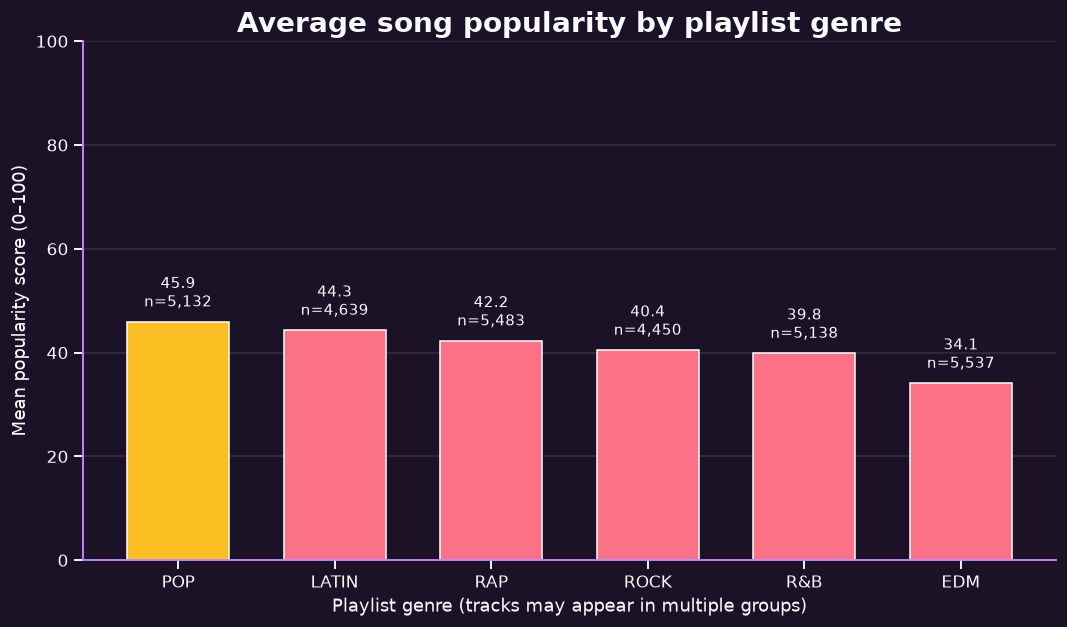

**Interpretation:** POP has the highest mean popularity (45.91), while EDM has the lowest (34.07) in this sample. Playlist selection and overlapping groups limit generalization; this is not a ranking of all Spotify genres.

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(genre_summary.index.str.upper(), genre_summary['mean_popularity'],
              color=[GOLD] + [CORAL] * (len(genre_summary) - 1), width=0.65)
ax.set(title='Average song popularity by playlist genre',
       xlabel='Playlist genre (tracks may appear in multiple groups)',
       ylabel='Mean popularity score (0–100)', ylim=(0, 100))
for bar, (genre, row) in zip(bars, genre_summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{row['mean_popularity']:.1f}\nn={int(row['song_count']):,}",
            ha='center', va='bottom', color=TEXT, fontsize=10)
finish_chart(fig, ax, 'genre_popularity.png')

display(Markdown(f"**Interpretation:** {genre_summary.index[0].upper()} has the highest mean popularity "
    f"({genre_summary.iloc[0]['mean_popularity']:.2f}), while {genre_summary.index[-1].upper()} "
    f"has the lowest ({genre_summary.iloc[-1]['mean_popularity']:.2f}) in this sample. "
    "Playlist selection and overlapping groups limit generalization; this is not a ranking of all Spotify genres."))

## 13. Chart 2 — Top 10 artists by average popularity
**Question:** which eligible artists have the highest average popularity? Require at least **20 distinct track IDs** to reduce rankings driven by one or two songs. This threshold is a transparent choice, not a significance test. Counts refer to tracks in this sample, not an artist's complete catalogue.

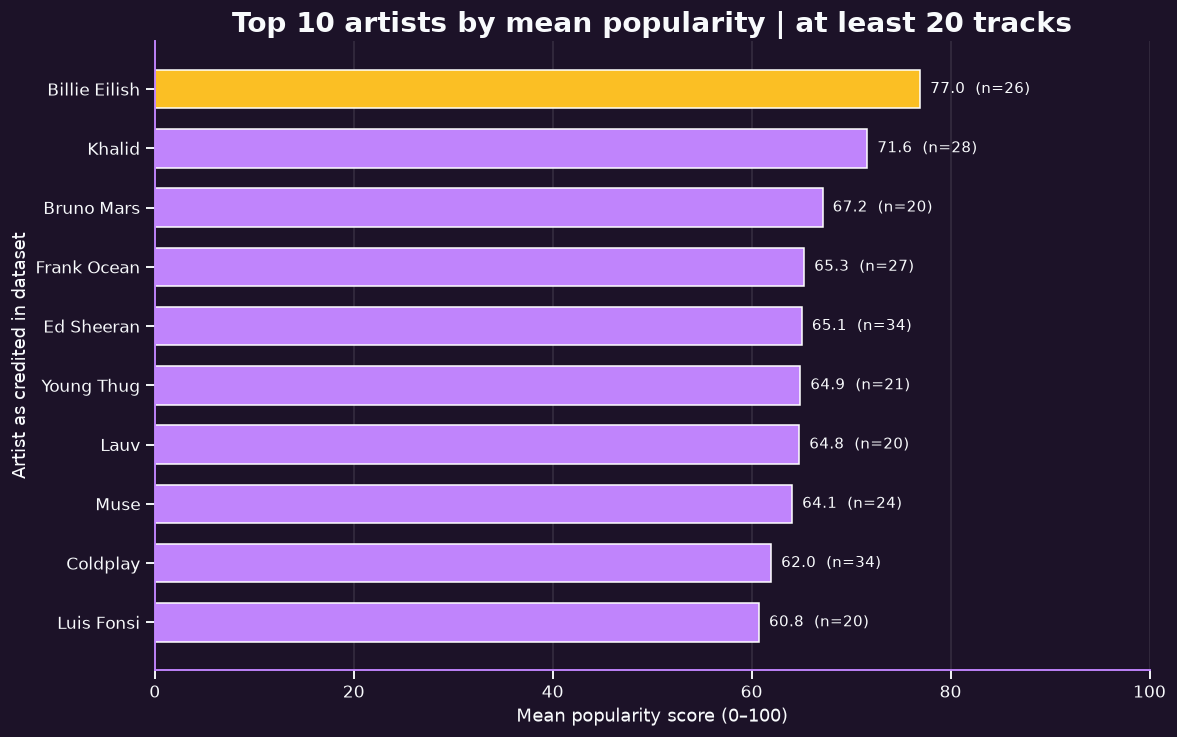

**Interpretation:** Billie Eilish leads the eligible artists with mean popularity 76.96 across 26 distinct tracks. 151 artist strings meet the threshold. The ranking depends on the sample and threshold; it does not measure total streams or worldwide artist popularity.

In [11]:
artist_plot = top_artists.iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(artist_plot.index, artist_plot['mean_popularity'],
               color=[VIOLET] * (len(artist_plot) - 1) + [GOLD], height=0.65)
ax.set(title=f'Top 10 artists by mean popularity | at least {MIN_SONGS} tracks',
       xlabel='Mean popularity score (0–100)', ylabel='Artist as credited in dataset', xlim=(0, 100))
for bar, (_, row) in zip(bars, artist_plot.iterrows()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{row['mean_popularity']:.1f}  (n={int(row['song_count'])})",
            va='center', color=TEXT, fontsize=10)
finish_chart(fig, ax, 'top_artists.png', grid_axis='x')

display(Markdown(f"**Interpretation:** {top_artists.index[0]} leads the eligible artists with "
    f"mean popularity {top_artists.iloc[0]['mean_popularity']:.2f} across "
    f"{int(top_artists.iloc[0]['song_count'])} distinct tracks. "
    f"{(artist_summary['song_count'] >= MIN_SONGS).sum()} artist strings meet the threshold. "
    "The ranking depends on the sample and threshold; it does not measure total streams or worldwide artist popularity."))

## 14. Chart 3 — Distribution of song duration
**Question:** how long are the songs? Use equal half-minute bins across the full observed range. Valid long tracks are retained. The vertical lines mark the mean and median.

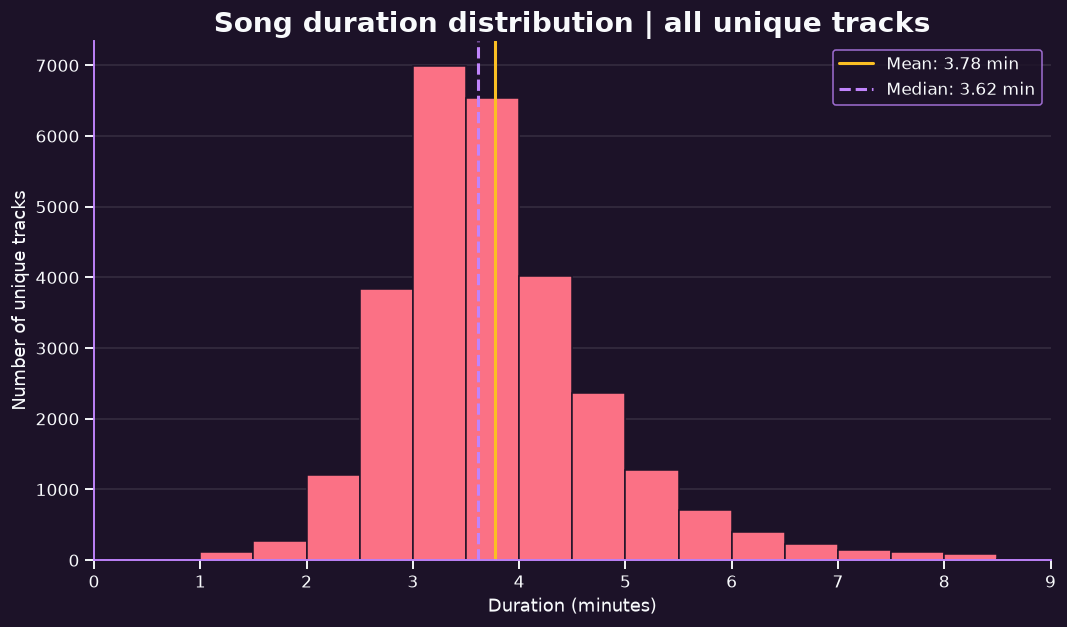

**Interpretation:** the mean duration is 3.78 minutes and the median is 3.62 minutes. 70.3% of tracks last 3–5 minutes (inclusive). The longest track is 8.63 minutes. The long-duration tail shows why the median is useful alongside the mean.

In [12]:
bins = np.arange(0, np.ceil(tracks['duration_min'].max() * 2) / 2 + 0.5, 0.5)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(tracks['duration_min'], bins=bins, color=CORAL, edgecolor=BG)
ax.axvline(duration_mean, color=GOLD, linewidth=2,
           label=f'Mean: {duration_mean:.2f} min')
ax.axvline(duration_median, color=VIOLET, linestyle='--', linewidth=2,
           label=f'Median: {duration_median:.2f} min')
ax.set(title='Song duration distribution | all unique tracks',
       xlabel='Duration (minutes)', ylabel='Number of unique tracks', xlim=(0, bins[-1]))
ax.legend(facecolor=BG, edgecolor=VIOLET, labelcolor=TEXT)
finish_chart(fig, ax, 'song_duration.png')

display(Markdown(f"**Interpretation:** the mean duration is {duration_mean:.2f} minutes and the "
    f"median is {duration_median:.2f} minutes. {between_3_5:.1f}% of tracks last 3–5 minutes "
    f"(inclusive). The longest track is {tracks['duration_min'].max():.2f} minutes. "
    "The long-duration tail shows why the median is useful alongside the mean."))

## 15. Chart 4 — Danceability versus popularity
**Question:** is there a linear relationship between danceability and popularity? Plot every unique track with smaller, more transparent markers (size 3, opacity 0.10) to reduce overlap. All 28,351 cleaned tracks are plotted; no sampling is used. The correlation uses the full unique-track table, not a plot sample. No regression or prediction model is fitted.

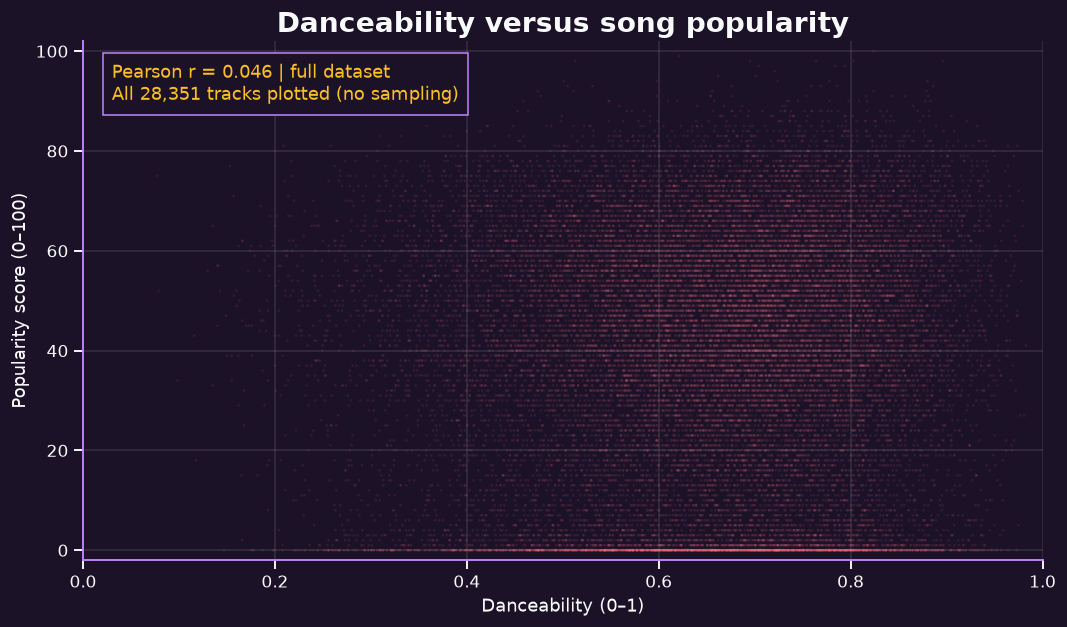

**Interpretation:** Pearson r = 0.046, a weak positive linear association under the descriptive rule |r| < 0.3 = weak, 0.3–0.7 = moderate, and ≥0.7 = strong. These cutoffs are guidelines. Danceability alone does not explain popularity; overlapping points and zero-popularity tracks are retained. Correlation is not causation.

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(tracks['danceability'], tracks['track_popularity'],
           s=3, color=CORAL, alpha=0.10, edgecolors='none', rasterized=True)
ax.set(title='Danceability versus song popularity', xlabel='Danceability (0–1)',
       ylabel='Popularity score (0–100)', xlim=(0, 1), ylim=(-2, 102))
ax.text(0.03, 0.96, f'Pearson r = {dance_r:.3f} | full dataset\nAll {len(tracks):,} tracks plotted (no sampling)',
        transform=ax.transAxes, va='top', color=GOLD,
        bbox=dict(facecolor=BG, edgecolor=VIOLET, pad=6))
finish_chart(fig, ax, 'danceability_vs_popularity.png', grid_axis='both')

strength = 'weak' if abs(dance_r) < 0.3 else ('moderate' if abs(dance_r) < 0.7 else 'strong')
direction = 'positive' if dance_r > 0 else 'negative'
display(Markdown(f"**Interpretation:** Pearson r = {dance_r:.3f}, a {strength} {direction} "
    "linear association under the descriptive rule |r| < 0.3 = weak, 0.3–0.7 = moderate, "
    "and ≥0.7 = strong. These cutoffs are guidelines. Danceability alone does not explain "
    "popularity; overlapping points and zero-popularity tracks are retained. Correlation is not causation."))

## 16. Chart 5 — Audio feature correlations
Pearson correlation measures linear association from −1 to +1. Violet shows negative values, gold positive values, and the dark midpoint represents zero. Values are annotated so color is not the only way to read the chart. Diagonal values are 1 because each feature correlates with itself.

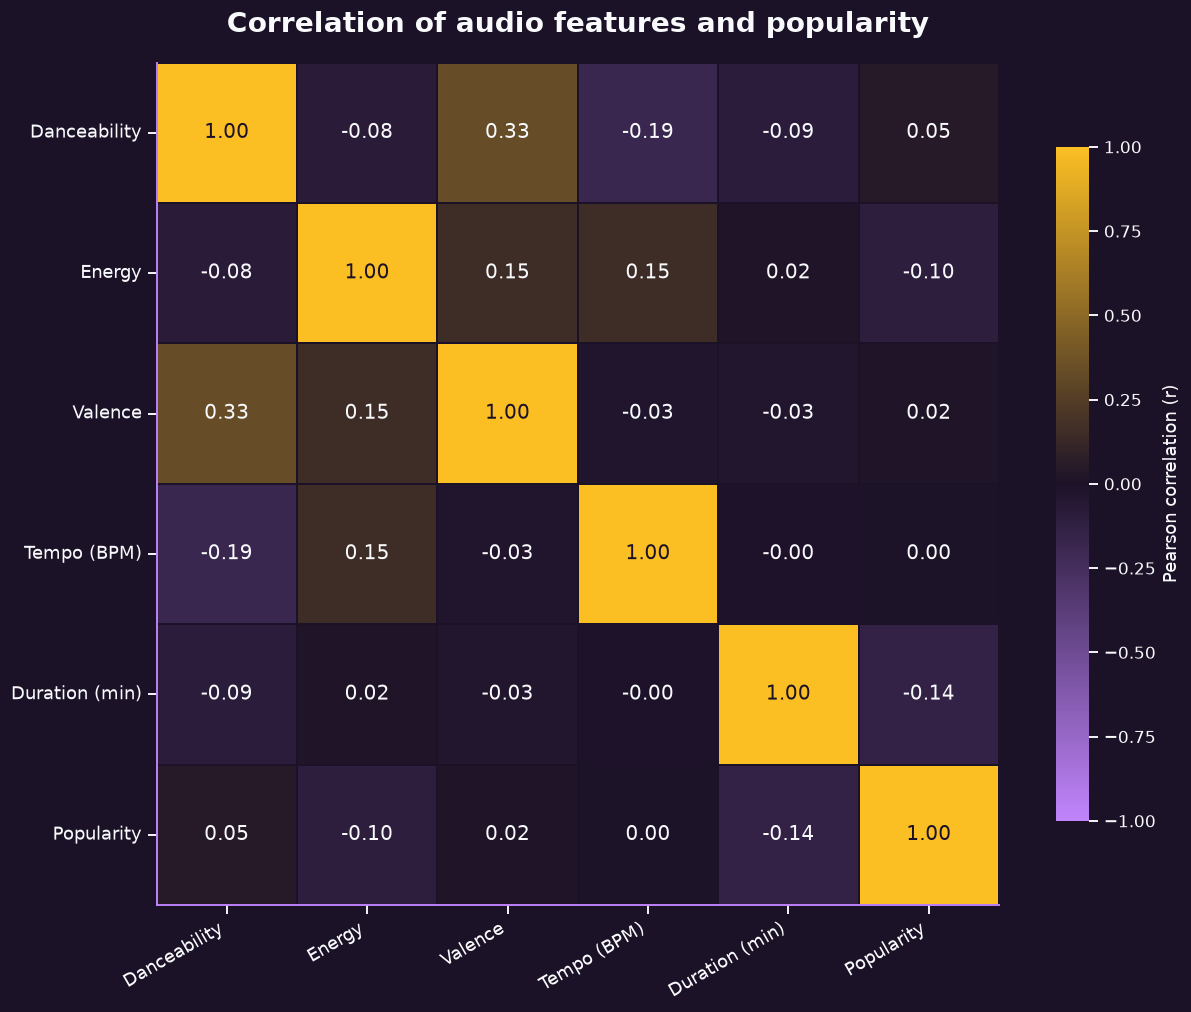

**Interpretation:** the strongest off-diagonal association among these selected features is danceability with valence (r = 0.334). The feature most correlated in absolute value with popularity is duration_min (r = -0.140). These associations describe the sample; they neither prove cause and effect nor demonstrate predictive accuracy.

In [14]:
labels = ['Danceability', 'Energy', 'Valence', 'Tempo (BPM)', 'Duration (min)', 'Popularity']
heatmap_data = correlations.copy()
heatmap_data.index = labels
heatmap_data.columns = labels
cmap = LinearSegmentedColormap.from_list('neon_sunset', [VIOLET, BG, GOLD])
fig, ax = plt.subplots(figsize=(12, 9.5))
sns.heatmap(heatmap_data, ax=ax, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, annot_kws={'fontsize': 13}, fmt='.2f', square=True, linewidths=1, linecolor=BG,
            cbar_kws={'label': 'Pearson correlation (r)', 'shrink': 0.8})
# Dark text on bright cells preserves contrast; light text on dark cells.
for annotation, value in zip(ax.texts, correlations.to_numpy().ravel()):
    annotation.set_color(BG if abs(value) >= 0.55 else TEXT)
ax.set_title('Correlation of audio features and popularity', pad=20)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=12)
ax.set_yticklabels(labels, rotation=0, fontsize=12)
finish_chart(fig, ax, 'correlation_heatmap.png', grid_axis=None)

upper = correlations.where(np.triu(np.ones(correlations.shape), k=1).astype(bool)).stack()
strongest_pair = upper.abs().idxmax()
strongest_r = upper.loc[strongest_pair]
pop_corr = correlations['track_popularity'].drop('track_popularity')
pop_feature = pop_corr.abs().idxmax()
display(Markdown(f"**Interpretation:** the strongest off-diagonal association among these selected "
    f"features is {strongest_pair[0]} with {strongest_pair[1]} (r = {strongest_r:.3f}). "
    f"The feature most correlated in absolute value with popularity is {pop_feature} "
    f"(r = {pop_corr[pop_feature]:.3f}). These associations describe the sample; they neither "
    "prove cause and effect nor demonstrate predictive accuracy."))

## 17. Overall findings

In [15]:
display(Markdown(f"""
- **Scope:** {len(raw):,} original playlist-track rows become {len(tracks):,} unique tracks for Charts 2–5, and {len(genre_tracks):,} track/genre pairs for Chart 1.
- **Genre:** {genre_summary.index[0].upper()} has the highest mean popularity ({genre_summary.iloc[0]['mean_popularity']:.2f}) in the playlist-genre comparison.
- **Artist:** {top_artists.index[0]} ranks first among artists with at least {MIN_SONGS} tracks ({top_artists.iloc[0]['mean_popularity']:.2f}).
- **Duration:** median {duration_median:.2f} minutes; {between_3_5:.1f}% of tracks are between 3 and 5 minutes.
- **Danceability:** its linear association with popularity is {strength} (r = {dance_r:.3f}).
- **Correlation:** {strongest_pair[0]} and {strongest_pair[1]} have the strongest selected feature-pair association (r = {strongest_r:.3f}).
"""))


- **Scope:** 32,833 original playlist-track rows become 28,351 unique tracks for Charts 2–5, and 30,379 track/genre pairs for Chart 1.
- **Genre:** POP has the highest mean popularity (45.91) in the playlist-genre comparison.
- **Artist:** Billie Eilish ranks first among artists with at least 20 tracks (76.96).
- **Duration:** median 3.62 minutes; 70.3% of tracks are between 3 and 5 minutes.
- **Danceability:** its linear association with popularity is weak (r = 0.046).
- **Correlation:** danceability and valence have the strongest selected feature-pair association (r = 0.334).


## 18. Limitations
- Historical January 2020 snapshot: no claims about current listening or changes over time.
- Playlist-selected sample: no random sampling of the entire Spotify catalogue.
- Playlist genre is a proxy; overlapping groups are not mutually exclusive.
- Distinct track IDs can represent versions of the same song. Artist strings can represent collaborations.
- Popularity is a bounded historical score, not a stream count. Zero scores are valid.
- The minimum artist count reduces one-song effects but does not remove selection bias or guarantee stable rankings.
- Pearson correlation describes linear association and is sensitive to unusual values. No hypothesis tests, causal inference or prediction are attempted.

## 19. Conclusion and result
The project successfully loads, inspects and cleans genuine Spotify metadata, then produces five consistent visualizations. Grouped averages describe differences within the sample, the histogram summarizes durations, and scatter and correlation plots examine linear relationships. The computed findings above answer the objectives while respecting the dataset's historical and sampling limitations.

**Result:** five 300 DPI PNG charts are saved in `charts/`, and their notebook outputs remain visible without rerunning the analysis.

### Short viva explanations
- **Why remove repeated track IDs?** Multiple playlists can contain the same recording, so playlist frequency should not inflate the song-level charts.
- **Why a different table for genres?** A track may belong to several playlist genres. Count it once in each genre to preserve those memberships, but only once overall in track-level charts so repeated playlist appearances do not give it extra weight.
- **Why use a mean for popularity?** It compares the average score per eligible group; counts explain the amount of supporting data.
- **Why show the median duration?** It is less affected by very long tracks than the mean.
- **Why require 20 tracks per artist?** An average based on one or two popular tracks can be misleading. Requiring at least 20 distinct tracks gives each ranked artist more supporting data, although the cutoff does not remove sampling bias.
- **What does r ≈ 0.046 mean?** Pearson correlation ranges from −1 to +1. A value this close to zero indicates almost no linear relationship: more danceable songs are not consistently more popular in this dataset. It does not rule out nonlinear relationships or prove causation.
- **Is this live Spotify data?** No. It is a historical January 2020 dataset; its popularity scores and artist rankings do not describe current 2026 listening.